# Multi-echo gradient echo

A multi-echo gradient echo reads the **same** line of k-space several times after one excitation,
so every echo is the same $k_y$ at a different point on the decay. That is what makes it the
sequence you reach for when the thing you want is a *map* rather than an image: $T_2^*$ from how
the magnitude falls across the train, and $\Delta B_0$ from how the phase turns.

There are two ways to play the train, and they are not interchangeable:

| | | |
|---|---|---|
| **monopolar** | every lobe the same sign, with a **fly-back** between them | one k grid, uniform echo times, ~25 % of the period spent flying back |
| **bipolar** | alternating sign, no fly-back | ~12 % shorter period and half the blocks, at a **reversed grid** on every second echo and echo times that alternate |

**This notebook defines no class.** Every other example directory here defines one — `MPRAGE2D`,
`SE2D`, `FSE2D`, `GREEPI2D`, `SEEPI2D` — because each of those sequences is a composition the
package does not have. A multi-echo GRE is not: it is a spoiled GRE whose readout was told to read
more than once, so the whole protocol is one `sc.modules.GRE2D(...)` call with two extra arguments.
Inventing a `MEGRE2D` to say so would be exactly the wrapper [`../README.md`](../README.md) warns
about. That is the finding, and it is worth stating rather than leaving to be noticed.

What *is* worth a notebook is the four numbers that are **wrong quietly**. Each one compiles,
passes every k-space extent check, and produces a plausible image — and each one surfaces only as a
wrong value in the map the sequence exists to produce:

1. **The reverse lobe's grid** (§1). Build a bipolar train out of the lobe that is correct for a
   single line and the two polarities sample grids **0.2051 $\Delta k$** apart.
2. **The fly-back's area** (§2). Minus the lobe's *total* area. The plausible wrong answer is a
   number the module already exposes, and it is only a factor of two out.
3. **The dwell** (§4). The guard is an ADC `delay`, and pypulseq divides those by
   `rf_raster_time`, not `adc_raster_time` — so a delay that is a whole number of ADC rasters and
   not of RF ones is refused at compile time, which
   `tests/modules/test_cartesian_line.py` pins as an oracle.
4. **The echo times** (§5). A bipolar train's $\Delta$TE alternates. Nothing checks it; a
   reconstruction that assumes it is uniform simply returns a **scaled** field map.

[`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) then simulates the files
written here against a phantom that carries the ground truth for **both** maps, so the fits are a
measurement rather than a picture.

## 0. The scanner, and the protocol

`opts` is a plain `pypulseq.Opts`. The three dead times are stated rather than defaulted: pypulseq
defaults all three to zero, which is wrong on every real scanner, and a sequence built on those
compiles and validates cleanly before the console refuses it.

The **slice is 3 mm** rather than the 5 mm the other 2D examples use, because a $T_2^*$ measurement
is the one that cares: through-slice field variation dephases within the voxel and *shortens the
measured $T_2^*$*, and a thinner slice is the honest way to reduce it. That is a real protocol
choice with a reason, which is why it is here and not buried.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

plt.rcParams['figure.dpi'] = 66

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=180, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM = (220.0, 220.0)      # (x, y)   -- readout, phase
MATRIX = (128, 128)          # (nx, ny) -- readout, phase
THICKNESS_MM = 3.0           # thin, because through-slice dephasing shortens the measured T2*
FLIP_DEG = 15.0
BANDWIDTH_HZ_PX = 500.0
ECHOES = 8
TR_S = 40e-3
DUMMIES = 8
PARTIAL_FOURIER = 0.75       # the fourth file, and section 5's worst case

NX, NY = MATRIX
CENTER_LINE = NY // 2
DK_X, DK_Y = 1e3 / FOV_MM[0], 1e3 / FOV_MM[1]

#: The reference bandwidth of `docs/multi_echo_api.md`, used wherever a measured number here is
#: quoted against that document.  The *protocol* runs at BANDWIDTH_HZ_PX; these are not the same
#: number, and every table below says which one it is at.
REFERENCE_BW_HZ_PX = 250.0

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)


def line(bandwidth_hz_px=BANDWIDTH_HZ_PX, **kwargs):
    """One `CartesianLine` on this protocol's readout axis."""
    return sc.modules.CartesianLine(opts=opts, fov_mm=FOV_MM[0], matrix=NX, axis='x',
                                    bandwidth_hz_px=bandwidth_hz_px, **kwargs)


def compiled(tree, name='probe', definitions=None):
    """Compile, keeping the warnings so a cell can assert on them rather than hide them."""
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', sc.SeqCraftWarning)
        seq = sc.compile(tree, opts, name=name, definitions=definitions)
    return seq, [str(w.message) for w in caught]


def gradient_kinds(seq, axis='gx'):
    """Every gradient type appearing on one axis of a compiled sequence."""
    return sorted({getattr(g, 'type', '?') for i in range(1, len(seq.block_events) + 1)
                   for g in (getattr(seq.get_block(i), axis, None),) if g is not None})


print(f'{NX} x {NY} over {FOV_MM[0]:.0f} mm, {THICKNESS_MM:.0f} mm slice, {FLIP_DEG:.0f} deg, '
      f'TR {TR_S * 1e3:.0f} ms, {ECHOES} echoes at {BANDWIDTH_HZ_PX:.0f} Hz/px asked for')
print(f'dk = {DK_X:.4f} 1/m along both axes')

128 x 128 over 220 mm, 3 mm slice, 15 deg, TR 40 ms, 8 echoes at 500 Hz/px asked for
dk = 4.5455 1/m along both axes


/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. The wrong lobe, first

`CartesianLine` builds its readout lobe by rounding the flat top **up** onto the gradient raster
and leaving the slack after the last sample. For **one line** that is exactly right: slack after
the last sample changes no k-space position, and it is also right for a *monopolar* train, where
every lobe is that same lobe.

It stops being right the moment a **reverse** lobe has to sample the same grid. A trapezoid is
symmetric about its own midpoint, so sample $i$ of a forward lobe and sample $N-1-i$ of a reverse
one land on the same $k$ **if and only if** the sampling window is exactly centred in the lobe:

$$T = 2g + N\tau \qquad\text{with equality, not "at least"}$$

The rounded lobe puts the window off-centre by half the rounding. Below, both lobes, built out of
raw pypulseq so that nothing is hidden, with `sc.kspace` reading the trajectory back off the
compiled waveform.

In [2]:
from seqcraft.design.timing import from_ticks, to_ticks
from seqcraft.modules._support import area_until, ceil_raster, halve_onto


def two_echo_grids(dwell_s, *, centred):
    """A prephaser, a forward lobe, a barrier and a reverse lobe.  Raw pypulseq throughout."""
    amplitude = DK_X / dwell_s
    sample_s = from_ticks(NX * to_ticks(dwell_s))
    if centred:
        # Rule 1: fix the duration first, split what is left equally between the two ends.
        rise_s = ceil_raster(amplitude / float(opts.max_slew), opts.grad_raster_time)
        total_s = ceil_raster(sample_s + 2 * max(float(opts.adc_dead_time), rise_s),
                              opts.grad_raster_time)
        guard_s = halve_onto(total_s, sample_s, opts.rf_raster_time, opts=opts)
        gx = pp.make_trapezoid(channel='x', amplitude=amplitude, rise_time=rise_s,
                               flat_time=total_s - 2 * rise_s, system=opts)
    else:
        # Today's lobe: the flat top rounded UP, the slack left after the last sample.
        gx = pp.make_trapezoid(channel='x', amplitude=amplitude, system=opts,
                               flat_time=ceil_raster(sample_s, opts.grad_raster_time))
        guard_s = float(gx.rise_time)

    adc = pp.make_adc(num_samples=NX, dwell=dwell_s, delay=guard_s, system=opts)
    lobe_s = float(pp.calc_duration(gx))
    pre = pp.make_trapezoid(channel='x', system=opts,
                            area=-area_until(gx, guard_s + (NX // 2 + 0.5) * dwell_s))

    out = sc.LogicBlock('two-echo').add(0.0, pre)
    t0 = float(pp.calc_duration(pre))
    out.add(t0, gx).add(t0, adc)
    out.add(t0 + lobe_s, sc.barrier('seam'))
    out.add(t0 + lobe_s, sc.events.derive(gx, amplitude=-amplitude)).add(t0 + lobe_s, adc)

    k = sc.kspace(out, opts)
    kx = np.asarray(k['k_adc'])[0]
    return dict(k=k, forward=kx[:NX], reverse=kx[NX:2 * NX], lobe_s=lobe_s,
                lead=guard_s, trail=lobe_s - guard_s - sample_s)


# 31.2 us is what the ADC raster gives at the reference bandwidth; 31.5 us is what the RF-raster
# quantum of section 4 gives.  Section 4 is why they differ; here only the *lobe* is under test.
GRIDS = {'rounded (today\'s lobe)': two_echo_grids(31.2e-6, centred=False),
         'centred (Rule 1)': two_echo_grids(31.5e-6, centred=True)}

print(f'{"":24s} {"lead":>8s} {"trailing":>9s} {"asymmetry":>10s} '
      f'{"max|k|":>10s} {"fwd vs reversed rev":>21s}')
for name, got in GRIDS.items():
    mismatch = float(np.max(np.abs(got['forward'] - got['reverse'][::-1])))
    extent = float(np.abs(np.concatenate([got['forward'], got['reverse']])).max())
    print(f'{name:24s} {got["lead"] * 1e6:7.2f}us {got["trail"] * 1e6:8.2f}us '
          f'{(got["trail"] - got["lead"]) * 1e6:9.2f}us {extent:10.4f} '
          f'{mismatch:11.4e} 1/m = {mismatch / DK_X:.4f} dk')

print()
print('Both rows have the SAME max|k| to four decimals.  A k-space *extent* check -- the obvious')
print('thing to write -- passes on both, and only the SIGNED difference between the two')
print('polarities separates them.  That is why every k assertion in this library is signed.')

                             lead  trailing  asymmetry     max|k|   fwd vs reversed rev
rounded (today's lobe)     20.00us    26.40us      6.40us   290.9091  9.3240e-01 1/m = 0.2051 dk
centred (Rule 1)           24.00us    24.00us      0.00us   290.9091  1.7053e-13 1/m = 0.0000 dk

Both rows have the SAME max|k| to four decimals.  A k-space *extent* check -- the obvious
thing to write -- passes on both, and only the SIGNED difference between the two
polarities separates them.  That is why every k assertion in this library is signed.


A fifth of a $\Delta k$ is not a rounding error. It is a **linear phase ramp between odd and even
echoes**, which is the exact thing a field map or a Dixon fit measures — so it never appears as an
artefact. It appears as a wrong number in the map, with no image to look wrong.

The plot makes the point the numbers cannot: the two trajectories are visually identical.

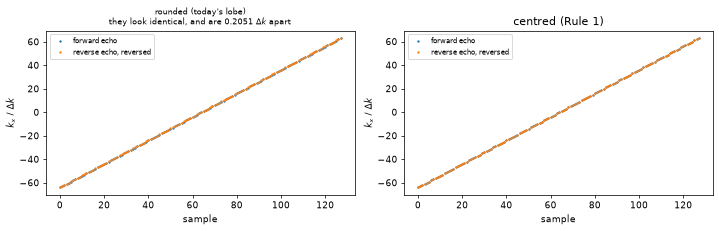

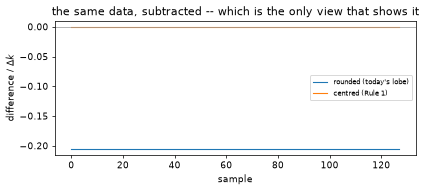

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (name, got) in zip(axes, GRIDS.items()):
    ax.plot(got['forward'] / DK_X, '.', ms=3, label='forward echo')
    ax.plot(got['reverse'][::-1] / DK_X, '.', ms=3, label='reverse echo, reversed')
    ax.set(xlabel='sample', ylabel='$k_x$ / $\\Delta k$', title=name)
    ax.legend(fontsize=8, loc='upper left')
axes[0].set_title(f'{list(GRIDS)[0]}\n'
                  f'they look identical, and are 0.2051 $\\Delta k$ apart', fontsize=9)
fig.tight_layout()

fig, ax = plt.subplots(figsize=(6.5, 3.0))
for name, got in GRIDS.items():
    ax.plot((got['forward'] - got['reverse'][::-1]) / DK_X, lw=1.2, label=name)
ax.axhline(0.0, color='0.6', lw=0.8)
ax.set(xlabel='sample', ylabel='difference / $\\Delta k$',
       title='the same data, subtracted -- which is the only view that shows it')
ax.legend(fontsize=8)
fig.tight_layout()

---
## 2. The fly-back, derived out loud

A monopolar train needs to return $k$ to where the prephaser left it between echoes, so that lobe
$n{+}1$ traverses the same trajectory lobe $n$ did. The area that does it is minus the lobe's
**total** area — ramps included, echo or no echo.

Three wrong answers are available, all of them plausible, all of them compiling:

```python
flyback_area = -gx.flat_area                # both ramps missing
flyback_area = -gx.area / 2                 # that is the prephaser's job, not this one
flyback_area = -ro.area_to_echo_per_m       # the PRE-echo part only
```

**The third is the dangerous one**, because it is a number the module already computes and already
exposes — and it is roughly half the right answer, which in a trajectory plot looks like a
plausible sequence rather than like a bug.

In [4]:
ro = line(REFERENCE_BW_HZ_PX)
gx = ro.gx
total = area_until(gx, float(pp.calc_duration(gx)))

CANDIDATES = {
    '-gx.flat_area': -float(gx.flat_area),
    '-gx.area / 2': -float(gx.area) / 2,
    '-area_to_echo_per_m': -ro.area_to_echo_per_m,
    '-total area  <- right': -total,
}
print(f'at the reference protocol, {REFERENCE_BW_HZ_PX:.0f} Hz/px:')
for name, area in CANDIDATES.items():
    print(f'  {name:24s} {area:14.6f} 1/m   ({abs(area / total) * 100:5.1f} % of the lobe)')

mono_ref = line(REFERENCE_BW_HZ_PX, echoes=6, polarity='monopolar')
print()
print(f'the module:              {mono_ref.flyback_area_per_m:14.6f} 1/m, '
      f'{mono_ref.flyback_duration_s * 1e6:.1f} us long')
assert mono_ref.flyback_area_per_m == -total
print()
print('area_to_echo_per_m is 294.638695 against 585.664336 -- the same order of magnitude and')
print('a factor of two apart.  Each echo would start half a k-space further along than the last,')
print('and the reconstruction would sum eight partial acquisitions believing they were eight')
print('echoes of one line.')

at the reference protocol, 250 Hz/px:
  -gx.flat_area               -582.750583 1/m   ( 99.5 % of the lobe)
  -gx.area / 2                -292.832168 1/m   ( 50.0 % of the lobe)
  -area_to_echo_per_m         -294.638695 1/m   ( 50.3 % of the lobe)
  -total area  <- right       -585.664336 1/m   (100.0 % of the lobe)

the module:                 -585.664336 1/m, 570.0 us long

area_to_echo_per_m is 294.638695 against 585.664336 -- the same order of magnitude and
a factor of two apart.  Each echo would start half a k-space further along than the last,
and the reconstruction would sum eight partial acquisitions believing they were eight
echoes of one line.


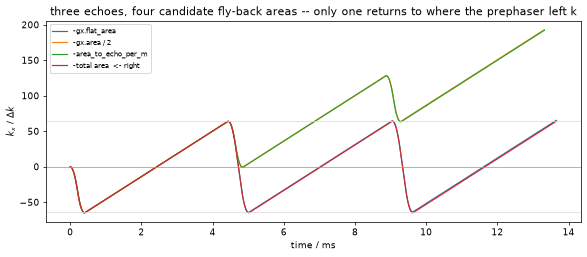

In [5]:
def trajectory(flyback_area, echoes=3):
    """Three lobes with a given fly-back area between them, read back through sc.kspace."""
    flyback = pp.make_trapezoid(channel='x', area=flyback_area, system=opts)
    lobe_s = float(pp.calc_duration(gx))
    period = ceil_raster(lobe_s + float(pp.calc_duration(flyback)), opts.grad_raster_time)
    out = sc.LogicBlock('probe').add(0.0, ro.prephaser_lobes[0])
    start = ro.prephaser_duration_s
    for n in range(echoes):
        t0 = start + n * period
        out.add(t0, gx).add(t0, ro.adc)
        if n + 1 < echoes:
            out.add(t0 + lobe_s, sc.barrier('seam'))
            out.add(t0 + lobe_s, flyback)
            out.add(start + (n + 1) * period, sc.barrier('lobe'))
    k = sc.kspace(out, opts)
    return np.asarray(k['k'][0]), np.asarray(k['t_k'])


fig, ax = plt.subplots(figsize=(9, 4.0))
for name, area in CANDIDATES.items():
    kx, t = trajectory(area)
    ax.plot(t * 1e3, kx / DK_X, lw=1.3, label=name)
ax.axhline(0.0, color='0.6', lw=0.8)
ax.axhline(NX / 2, color='0.85', lw=0.8)
ax.axhline(-NX / 2, color='0.85', lw=0.8)
ax.set(xlabel='time / ms', ylabel='$k_x$ / $\\Delta k$',
       title='three echoes, four candidate fly-back areas -- '
             'only one returns to where the prephaser left k')
ax.legend(fontsize=8)
fig.tight_layout()

---
## 3. The barriers, and where the block boundaries actually fall

A block may hold at most one gradient per axis and at most one ADC, so somewhere between two
consecutive echoes the compiler has to cut a block boundary. `CartesianLine` states where with
`sc.barrier`: **one** at each seam under bipolar, **two** under monopolar — at the fly-back's start
and at its end, one per gradient edge.

It is reasonable to expect that without them the compiler would cut at the midpoint of the legal
gap between consecutive ADCs, land *inside* a lobe, and split it into two arbitrary waveforms —
reported only by a `merge` warning. **For this train it does not**, and the table below is how we
know: two barriers, one, and none compile to the identical block count, with every gradient still
a `trap` and no warning at all.

The reason is in `seqcraft.compiler.boundaries.find_boundaries`: alongside the *mandatory* boundary
in each gap between exclusive events, every **gradient edge** is an *opportunistic* candidate,
accepted whenever it falls strictly inside no gradient and no indivisible span. Every seam in this
design is exactly such an edge — the lobe ends where the fly-back starts, the fly-back ends where
the next lobe starts, and nothing overlaps either join.

That is precisely the difference from `EPI2D`, whose blip is **centred on** the seam and therefore
*covers* it: there the seam is not an acceptable candidate, the compiler falls back to the
mandatory midpoint, and the midpoint is inside the readout lobe.

The barriers stay anyway, and not out of superstition: that opportunistic rule is documented as *a
preference, not a requirement*, and one `sc.barrier` per gradient edge makes this train's block
structure a property of the design rather than a consequence of a preference. They cost nothing —
the emitted file is byte-identical with and without.

In [6]:
def rebuilt(train, barriers):
    """The same train with `barriers` of the two barriers per seam kept."""
    period, lobe_s = train.echo_spacing_s, float(pp.calc_duration(train.gx))
    out = sc.LogicBlock(f'{barriers}-barriers').add(0.0, train.prephaser_lobes[0])
    start = train.prephaser_duration_s
    for n in range(train.echoes):
        t0 = start + n * period
        out.add(t0, train.gx if train.polarity_of(n) > 0 else train._gx_reverse)
        out.add(t0, train.adc)
        if n + 1 < train.echoes:
            if barriers >= 1:
                out.add(t0 + lobe_s, sc.barrier('seam'))
            if train._flyback is not None:
                out.add(t0 + lobe_s, train._flyback)
                if barriers >= 2:
                    out.add(start + (n + 1) * period, sc.barrier('lobe'))
    return out


mono = line(echoes=ECHOES, polarity='monopolar')
bipolar = line(echoes=ECHOES, polarity='bipolar')

print(f'{"polarity":10s} {"barriers":>9s} {"blocks":>7s} {"gx events":>11s} {"merges":>7s}')
for name, train in (('monopolar', mono), ('bipolar', bipolar)):
    for barriers in (2, 1, 0):
        seq, caught = compiled(rebuilt(train, barriers))
        merges = [w for w in caught if 'merge' in w]
        print(f'{name:10s} {barriers:9d} {len(seq.block_events):7d} '
              f'{",".join(gradient_kinds(seq)):>11s} {len(merges):7d}')

print()
print('Three identical rows per polarity.  The barriers are not what keeps the lobes whole here;')
print('the compiler already cuts at gradient edges.  They are what states it.')

polarity    barriers  blocks   gx events  merges
monopolar          2      16        trap       0
monopolar          1      16        trap       0
monopolar          0      16        trap       0
bipolar            2       9        trap       0
bipolar            1       9        trap       0
bipolar            0       9        trap       0

Three identical rows per polarity.  The barriers are not what keeps the lobes whole here;
the compiler already cuts at gradient edges.  They are what states it.


---
## 4. The dwell moves under `bipolar`

This is the finding that most changes what a caller sees, and it is not guessable from pulseq's
specification.

A centred window makes the guard the ADC's own `delay`. pypulseq's `_check_timing_block` divides an
`adc`, `rf` or `output` event's delay by **`rf_raster_time`** — 1 µs on Siemens — and everything
else by `grad_raster_time`. The ADC raster the *dwell* lives on is ten times finer and does not
come into it. Since the lobe is on the gradient raster, the whole burden falls on
$N\tau$, which must be an even number of RF rasters.

`seqcraft.modules._support.dwell_quantum` solves that in integer ticks rather than searching: with
$a$ the ADC raster and $u = 2\,t_\mathrm{RF}$, a dwell of $k a$ works exactly when $k$ is a multiple
of $u / \gcd(Na, u)$. At 128 samples that is a multiple of **500 ns** — five ADC rasters.

Rounded **up**, never to nearest: rounding down raises the bandwidth, which shortens the lobe,
which is the direction that turns a feasible protocol into a refusal.

**So the same request produces a different bandwidth in the two modes.** That is a fact about the
file, it belongs in the protocol table, and `bandwidth_hz_px` reads back what was achieved.

In [7]:
from seqcraft.modules._support import dwell_quantum

quantum = dwell_quantum(NX, opts=opts)
print(f'ADC raster {opts.adc_raster_time * 1e9:.0f} ns   '
      f'RF raster {opts.rf_raster_time * 1e9:.0f} ns   '
      f'quantum at {NX} samples {quantum * 1e9:.0f} ns\n')

print(f'{"asked":>8s} {"mono dwell":>11s} {"achieved":>10s} {"bi dwell":>10s} {"achieved":>10s} '
      f'{"difference":>11s}')
for bw in (250.0, 400.0, 500.0, 700.0, 1000.0):
    m, b = line(bw, echoes=4, polarity='monopolar'), line(bw, echoes=4, polarity='bipolar')
    print(f'{bw:7.0f}  {m.dwell_s * 1e6:9.2f}us {m.bandwidth_hz_px:9.1f} '
          f'{b.dwell_s * 1e6:8.2f}us {b.bandwidth_hz_px:9.1f} '
          f'{100 * (b.bandwidth_hz_px / m.bandwidth_hz_px - 1):10.2f} %')

print()
print(f'and the guard lands where it has to: {ECHOES}-echo bipolar at '
      f'{BANDWIDTH_HZ_PX:.0f} Hz/px has an ADC delay of '
      f'{float(bipolar.adc.delay) * 1e6:.2f} us, which is '
      f'{float(bipolar.adc.delay) / opts.rf_raster_time:.0f} RF rasters exactly.')
residue = (bipolar.echo_spacing_s - 2 * float(bipolar.adc.delay)
           - bipolar.num_samples * bipolar.dwell_s)
print(f'Rule 1, measured: T - 2g - N.tau = {residue * 1e9:.3f} ns')

ADC raster 100 ns   RF raster 1000 ns   quantum at 128 samples 500 ns

   asked  mono dwell   achieved   bi dwell   achieved  difference
    250      31.20us     250.4    31.50us     248.0      -0.95 %
    400      19.50us     400.6    20.00us     390.6      -2.50 %
    500      15.60us     500.8    16.00us     488.3      -2.50 %
    700      11.20us     697.5    11.50us     679.3      -2.61 %
   1000       7.80us    1001.6     8.00us     976.6      -2.50 %

and the guard lands where it has to: 8-echo bipolar at 500 Hz/px has an ADC delay of 41.00 us, which is 41 RF rasters exactly.
Rule 1, measured: T - 2g - N.tau = 0.000 ns


---
## 5. `te_s` is not `echo_spacing_s`, and the difference is a scale error

`k = 0` is a **sample**, not an instant. It sits at index `pre_echo_samples` on a forward lobe and
at `num_samples - 1 - pre_echo_samples` on a reverse one — two *different* distances into two
identical lobes:

$$t_\text{forward} = g + (p + \tfrac12)\tau, \qquad
  t_\text{reverse} = g + (N - p - \tfrac12)\tau$$

So a bipolar train's echo **times** are not uniformly spaced even though its lobes are. At
`partial_fourier = 1.0` and even $N$, $p = N/2$, and the two differ by exactly one dwell: the
intervals alternate $T-\tau,\ T+\tau,\ T-\tau,\dots$

The closed form for the spread is $2\,|N - 1 - 2p|\,\tau$, and **partial echo makes it enormous** —
at `partial_fourier = 0.75` the echo sits a third of the way into a forward lobe and two thirds
into a reverse one.

In [8]:
print(f'{"pf":>5s} {"polarity":10s} {"period":>9s} {"dTE min":>9s} {"dTE max":>9s} '
      f'{"spread":>10s} {"closed form":>12s}')
TRAINS = {}
for bw in (REFERENCE_BW_HZ_PX, BANDWIDTH_HZ_PX):
    print(f'-- at {bw:.0f} Hz/px')
    for pf in (1.0, PARTIAL_FOURIER):
        for pol in ('monopolar', 'bipolar'):
            t = line(bw, echoes=ECHOES, polarity=pol, partial_fourier=pf)
            TRAINS[bw, pf, pol] = t
            gaps = np.diff(t.te_s)
            # The closed form is a statement about the *reversal*, so it is zero where there is
            # none: a monopolar train plays one lobe design and its echo times are uniform.
            closed = (0.0 if pol == 'monopolar'
                      else 2 * abs(t.num_samples - 1 - 2 * t.pre_echo_samples) * t.dwell_s)
            print(f'{pf:5.2f} {pol:10s} {t.echo_spacing_s * 1e6:8.1f}us '
                  f'{gaps.min() * 1e6:8.2f}us {gaps.max() * 1e6:8.2f}us '
                  f'{np.ptp(gaps) * 1e6:9.2f}us {closed * 1e6:11.2f}us')
            assert abs(np.ptp(gaps) - closed) < 1e-12

t = TRAINS[BANDWIDTH_HZ_PX, PARTIAL_FOURIER, 'bipolar']
print()
print(f'at pf {PARTIAL_FOURIER} the echo sample alternates '
      f'{[t.echo_sample(n) for n in range(4)]} rather than staying at {t.pre_echo_samples}.')
print('The data is exact either way.  What is not merely imprecise but *meaningless* is the')
print('uniform dTE a caller might assume.')

   pf polarity      period   dTE min   dTE max     spread  closed form
-- at 250 Hz/px
 1.00 monopolar    4610.0us  4610.00us  4610.00us      0.00us        0.00us
 1.00 bipolar      4080.0us  4048.50us  4111.50us     63.00us       63.00us
 0.75 monopolar    3530.0us  3530.00us  3530.00us      0.00us        0.00us
 0.75 bipolar      3070.0us  2093.50us  4046.50us   1953.00us     1953.00us
-- at 500 Hz/px
 1.00 monopolar    2660.0us  2660.00us  2660.00us      0.00us        0.00us
 1.00 bipolar      2130.0us  2114.00us  2146.00us     32.00us       32.00us
 0.75 monopolar    2070.0us  2070.00us  2070.00us      0.00us        0.00us
 0.75 bipolar      1620.0us  1124.00us  2116.00us    992.00us      992.00us

at pf 0.75 the echo sample alternates [32, 63, 32, 63] rather than staying at 32.
The data is exact either way.  What is not merely imprecise but *meaningless* is the
uniform dTE a caller might assume.


### What assuming a uniform $\Delta$TE actually costs

This is arithmetic, not simulation — it needs nothing but `te_s`, which is the point of putting it
in `01`. Take a known off-resonance, evolve the phase against the **true** echo times, then fit it
back as if $\Delta$TE were the period.

A least-squares fit over eight echoes barely moves, because a symmetric alternation largely cancels.
**A two-point field map is the case that does not cancel** — and a scale error in a field map is
exactly the kind of wrong that no image inspection finds.

In [9]:
TRUE_HZ = 45.0                       # the phantom's own maximum, so this is not a strawman
bi = TRAINS[BANDWIDTH_HZ_PX, 1.0, 'bipolar']
te = np.array(bi.te_s)
assumed = te[0] + np.arange(ECHOES) * bi.echo_spacing_s        # the wrong axis
phase = 2 * np.pi * TRUE_HZ * te                               # the right physics

against_te = np.polyfit(te, phase, 1)[0] / (2 * np.pi)
against_period = np.polyfit(assumed, phase, 1)[0] / (2 * np.pi)
two_point = (phase[1] - phase[0]) / (2 * np.pi * bi.echo_spacing_s)

print(f'a {TRUE_HZ:.0f} Hz offset through an {ECHOES}-echo bipolar train:')
print(f'  fitted against te_s                {against_te:9.4f} Hz  '
      f'{100 * (against_te / TRUE_HZ - 1):+8.4f} %')
print(f'  fitted against TE1 + n*period      {against_period:9.4f} Hz  '
      f'{100 * (against_period / TRUE_HZ - 1):+8.4f} %')
print(f'  two-point, divided by the period   {two_point:9.4f} Hz  '
      f'{100 * (two_point / TRUE_HZ - 1):+8.4f} %')
print()
print(f'The two-point error is a SCALE error, so it grows with the field: '
      f'{abs(two_point - TRUE_HZ):.2f} Hz at {TRUE_HZ:.0f} Hz and '
      f'{abs(two_point - TRUE_HZ) / TRUE_HZ * 400:.1f} Hz at 400.')
print('Section 2 of `02` confirms all three against a simulation.')

print()
print('And the range each protocol can measure without wrapping, +/- 1/(2 dTE):')
for name, train in (('monopolar', mono), ('bipolar', bipolar)):
    print(f'  {name:10s} +/- {1 / (2 * train.echo_spacing_s):6.1f} Hz')
print('against a phantom spanning -11 to +45 Hz.  Section 5 of `02` demonstrates that rather')
print('than quoting it.')

a 45 Hz offset through an 8-echo bipolar train:
  fitted against te_s                  45.0000 Hz   -0.0000 %
  fitted against TE1 + n*period        44.9839 Hz   -0.0358 %
  two-point, divided by the period     44.6620 Hz   -0.7512 %

The two-point error is a SCALE error, so it grows with the field: 0.34 Hz at 45 Hz and 3.0 Hz at 400.
Section 2 of `02` confirms all three against a simulation.

And the range each protocol can measure without wrapping, +/- 1/(2 dTE):
  monopolar  +/-  188.0 Hz
  bipolar    +/-  234.7 Hz
against a phantom spanning -11 to +45 Hz.  Section 5 of `02` demonstrates that rather
than quoting it.


---
## 6. The protocol, and what it is chosen for

8 echoes, 500 Hz/px asked for, 220 mm, 128 × 128, 3 mm, 15°, TR 40 ms.

- **8 echoes** so that a $T_2^*$ fit has something to fit. Grey matter at 3 T is around 50 ms and
  the monopolar train reaches TE₈ ≈ 20 ms, which samples the first half of the decay — where the
  SNR is.
- **500 Hz/px** sets the lobe, and with it the echo spacing. §4's table is why the two polarities
  do not achieve the same number from that one request.
- **15°** is above the Ernst angle for TR 40 ms — this is a $T_2^*$ measurement, not a $T_1$-weighted
  image, and the extra transverse signal is what the fit is made of.
- **TR 40 ms** leaves room for the monopolar train (min TR ≈ 26 ms) and the same number is used for
  every file, so `02` compares readouts rather than contrasts.

**`GRE2D` takes the whole protocol.** No class, no wrapper — the two extra arguments are the
sequence.

In [10]:
def scan(**kwargs):
    """The protocol, with only the readout arguments varying between files."""
    return sc.modules.GRE2D(
        opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM, flip_deg=FLIP_DEG,
        bandwidth_hz_px=BANDWIDTH_HZ_PX, tr_s=TR_S, **kwargs)


SCANS = {
    'megre_mono': scan(echoes=ECHOES, polarity='monopolar'),
    'megre_bipolar': scan(echoes=ECHOES, polarity='bipolar'),
    'megre_mono_pf075': scan(echoes=ECHOES, polarity='monopolar',
                             partial_fourier=PARTIAL_FOURIER),
}

print(f'{"file":18s} {"polarity":10s} {"BW":>7s} {"dTE":>9s} {"TE1":>8s} {"TE8":>9s} '
      f'{"min TR":>8s} {"train":>8s}')
for name, s in SCANS.items():
    ro = s.tr.ro
    print(f'{name:18s} {ro.polarity:10s} {ro.bandwidth_hz_px:6.1f} '
          f'{ro.echo_spacing_s * 1e6:8.1f}us {ro.te_s[0] * 1e3:7.4f} {ro.te_s[-1] * 1e3:8.4f} '
          f'{s.tr.min_tr_s * 1e3:7.2f}ms {ro().duration * 1e3:7.3f}ms')

print()
print('TE above is measured from the READOUT BLOCK, which is what `CartesianLine.te_s` reports.')
print('The protocol TE -- from the excitation centre, which is what a scanner console shows -- is')
print('longer by the winder:')
for name, s in SCANS.items():
    protocol_te = np.array(s.tr.ro.te_s) + (s.tr.te_s - s.tr.ro.te_s[0])
    print(f'  {name:18s} TE1 {protocol_te[0] * 1e3:6.4f} ms   TE8 {protocol_te[-1] * 1e3:7.4f} ms')

file               polarity        BW       dTE      TE1       TE8   min TR    train
megre_mono         monopolar   500.8   2660.0us  1.6762  20.2962   26.09ms  21.330ms
megre_bipolar      bipolar     488.3   2130.0us  1.7030  16.5970   22.43ms  17.670ms
megre_mono_pf075   monopolar   500.8   2070.0us  1.1770  15.6670   21.46ms  16.700ms

TE above is measured from the READOUT BLOCK, which is what `CartesianLine.te_s` reports.
The protocol TE -- from the excitation centre, which is what a scanner console shows -- is
longer by the winder:
  megre_mono         TE1 3.2362 ms   TE8 21.8562 ms
  megre_bipolar      TE1 3.2630 ms   TE8 18.1570 ms
  megre_mono_pf075   TE1 2.7370 ms   TE8 17.2270 ms


In [11]:
# The pin that keeps `02`'s comparison honest: everything except the readout is identical.
shared = {name: (s.tr.exc.flip_deg, round(s.tr.tr_s, 12), s.tr.matrix, s.tr.thickness_mm,
                 s.rf_spoil_deg, s.center_line)
          for name, s in SCANS.items()}
assert len(set(shared.values())) == 1, shared
flip, tr_s, matrix, slice_mm, spoil_deg, centre = next(iter(shared.values()))
print(f'identical across every imaging file:')
print(f'  flip {flip:.1f} deg   TR {tr_s * 1e3:.1f} ms   matrix {matrix}   '
      f'slice {slice_mm:.1f} mm')
print(f'  RF spoiling {spoil_deg:.0f} deg   centre line {centre}')
print()
print('So `02` compares readouts rather than contrasts -- which is the only way its T2* numbers')
print('from two files can be put on the same axis.')

identical across every imaging file:
  flip 15.0 deg   TR 40.0 ms   matrix (128, 128)   slice 3.0 mm
  RF spoiling 117 deg   centre line 64

So `02` compares readouts rather than contrasts -- which is the only way its T2* numbers
from two files can be put on the same axis.


---
## 7. Three files

The protocol above, twice over for the two polarities, and once more with a partial echo.

Every file carries `echoes`, `polarity` and the **`te_s` array** in its `[DEFINITIONS]`, so `02`
reads the echo times *out of the file* rather than rebuilding the module. That is the same
discipline `gre_epi_2d/02` applies by parsing the written `.seq` with MRzero: if the reconstruction
can only work by re-deriving the sequence, the file is not self-describing.

In [12]:
def write(name, module, *, lines=None, dummies=DUMMIES, extra=None):
    """Compile one acquisition, record what a reconstruction needs, and write it."""
    table = list(range(NY)) if lines is None else list(lines)
    tree = module(lines=table, dummies=dummies)
    ro = module.tr.ro
    # The echo times a fit is run against, measured from the EXCITATION, which is what TE means
    # to a reconstruction.  `ro.te_s` is measured from the readout block; the offset is the winder.
    offset = module.tr.te_s - ro.te_s[0]
    te_s = [float(t + offset) for t in ro.te_s]
    definitions = {
        'FOV': [FOV_MM[0] / 1e3, FOV_MM[1] / 1e3, THICKNESS_MM / 1e3],
        'SliceThickness': THICKNESS_MM / 1e3,
        'kSpaceCenterLine': CENTER_LINE,
        'TE': te_s,
        'TR': module.tr.tr_s,
        'ReceiverBandwidth': ro.bandwidth_hz_px,
        'Echoes': ro.echoes,
        'Polarity': ro.polarity,
        'EchoSpacing': ro.echo_spacing_s,
        'EchoSamples': [ro.echo_sample(n) for n in range(ro.echoes)],
        'EchoPolarity': [ro.polarity_of(n) for n in range(ro.echoes)],
        'NumSamples': ro.num_samples,
        'PartialFourier': ro.partial_fourier,
        'FlipAngle': module.tr.exc.flip_deg,
        **(extra or {}),
    }
    seq, caught = compiled(tree, name, definitions)
    seq.write(str(SEQ_DIR / f'{name}.seq'))
    merges = [w for w in caught if 'merge' in w]
    assert gradient_kinds(seq) == ['trap'], gradient_kinds(seq)
    assert not merges, merges
    print(f'-> {name + ".seq":22s} {len(seq.block_events):6d} blocks  '
          f'{seq.duration()[0]:7.3f} s  {len(table)} lines x {ro.echoes} echoes  '
          f'TE {te_s[0] * 1e3:.3f} .. {te_s[-1] * 1e3:.3f} ms')
    return seq


WRITTEN = {name: write(name, module) for name, module in SCANS.items()}

-> megre_mono.seq           2584 blocks    5.440 s  128 lines x 8 echoes  TE 3.236 .. 21.856 ms


-> megre_bipolar.seq        1632 blocks    5.440 s  128 lines x 8 echoes  TE 3.263 .. 18.157 ms


-> megre_mono_pf075.seq     2584 blocks    5.440 s  128 lines x 8 echoes  TE 2.737 .. 17.227 ms


---
## What `02` does with these

| file | what it is for |
|---|---|
| `megre_mono.seq` | the $T_2^*$ and $\Delta B_0$ fits, against the phantom's own maps |
| `megre_bipolar.seq` | the same maps off a train whose every second echo is reversed |
| `megre_mono_pf075.seq` | partial echo: a shorter TE₁, 96 of 128 $k_x$ points, and a POCS reconstruction |

The two oracles are in the phantom rather than in the fit, which is what makes `02` a measurement:
`subject05.npz` carries **T2′** as well as T2, so $1/(1/T_2 + 1/T_2')$ is the true $T_2^*$
voxelwise, and `phantom.field_hz()` is the B0 map the simulation actually ran against.

`02` reconstructs all three the same way — ESPIRiT coil maps, then SENSE, with POCS first for the
partial echo — so what differs between its pictures is the readout and not the reconstruction.